In [2]:
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
# Add the head direcoty to sys.path
workspace_root = os.getcwd()  
sys.path.insert(0, workspace_root + "/../../../../")

# import this repo's classes
from pyanalib.split_df_helpers import *
import pyanalib.pandas_helpers as ph
from makedf.util import *
import loaddf
from pot import *
import gump_cuts as gc
import kinematics
from tqdm.auto import tqdm


In [3]:
class PlotObj:
  def __init__(self, title, label):
    self.title = title
    self.label = label

# Colors for plots
HAWKS_COLORS = ["#315031", "#d54c28", "#1e3f54", "#c89648", "#43140b", "#95af8b"]
FONTSIZE = 14
plt.style.use('/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/dune.mplstyle')

In [48]:
def make_all_plots(df_nd, df_fd, cut_stage, mode_labels, top_labels, det_labels):
    sbnd_title = f"{cut_stage}"
    icarus_title = f"{cut_stage}"

    #sbnd_file_p = f"intdelp_{cut_stage.lower().replace(' ', '_')}_sbnd.png"
    #icarus_file_p = f"intdelp_{cut_stage.lower().replace(' ', '_')}_icarus.png"
    #plot_int(df_nd, 'del_p', sbnd_title, sbnd_file_p, r"$\delta p$ [GeV/c]", mode_labels, det_labels[0])
    #plot_int(df_fd, 'del_p', icarus_title, icarus_file_p, r"$\delta p$ [GeV/c]", mode_labels, det_labels[1])

    #sbnd_file_pT = f"intdelpT_{cut_stage.lower().replace(' ', '_')}_sbnd.png"
    #icarus_file_pT = f"intdelpT_{cut_stage.lower().replace(' ', '_')}_icarus.png"
    #plot_int(df_nd, 'del_Tp', sbnd_title, sbnd_file_pT, r"$\delta p_{T}$ [GeV/c]", mode_labels, det_labels[0])
    #plot_int(df_fd, 'del_Tp', icarus_title, icarus_file_pT, r"$\delta p_{T}$ [GeV/c]", mode_labels, det_labels[1])

    #sbnd_file_E = f"intE_{cut_stage.lower().replace(' ', '_')}_sbnd.png"
    #icarus_file_E = f"intE_{cut_stage.lower().replace(' ', '_')}_icarus.png"
    #plot_int(df_nd, 'nu_E_calo', sbnd_title, sbnd_file_E, r"$E_{reco}$ [GeV]", mode_labels, det_labels[0])
    #plot_int(df_fd, 'nu_E_calo', icarus_title, icarus_file_E, r"$E_{reco}$ [GeV]", mode_labels, det_labels[1])

    #sbnd_fs_file = f"fs_{cut_stage.lower().replace(' ', '_')}_sbnd.png"
    #icarus_fs_file = f"fs_{cut_stage.lower().replace(' ', '_')}_icarus.png"
    #plot_fs(df_nd, sbnd_title, sbnd_fs_file, det_labels[0])
    #plot_fs(df_fd, icarus_title, icarus_fs_file, det_labels[1])

    sbnd_file_top = f"topE_{cut_stage.lower().replace(' ', '_')}_sbnd.png"
    icarus_file_top = f"topE_{cut_stage.lower().replace(' ', '_')}_icarus.png"
    sbnd_comp = plot_top(df_nd, 'nu_E_calo', sbnd_title, sbnd_file_top, r"$E_{reco}$ [GeV]", top_labels, det_labels[0], eff_bool=True)
    icarus_comp = plot_top(df_fd, 'nu_E_calo', icarus_title, icarus_file_top, r"$E_{reco}$ [GeV]", top_labels, det_labels[1], eff_bool=True)
    sbnd_comp = plot_top(df_nd, 'del_p', sbnd_title, sbnd_file_top, r"$\delta p$ [GeV]", top_labels, det_labels[0], eff_bool=True)
    icarus_comp = plot_top(df_fd, 'del_p', icarus_title, icarus_file_top, r"$\delta p$ [GeV]", top_labels, det_labels[1], eff_bool=True)
    return sbnd_comp, icarus_comp

def plot_top(df, var, title, outfile, label, mode_labels, det, eff_bool=False):
    var_data = df[var]
    og_sig_ct = df['og_sig_ct'].to_numpy()[0]
    glob_scale = df['glob_scale'].to_numpy()[0]
    tvar = gc.breakdown_top(var_data, df)

    # Do purity/efficiency calculation
    ret = [len(t) for t in tvar]
    sig_ct = ret[0]
    tot_ct = sum(ret)
    eff = sig_ct/og_sig_ct
    pur = sig_ct/tot_ct

    fig, ax = plt.subplots(1, 1, figsize=(6, 4.5))
    plt.xlabel(label)
    plt.ylabel('Events')

    n, bins, _ = plt.hist(tvar, bins=np.linspace(0,2.5,21), stacked=True, label=top_labels,
                        color=HAWKS_COLORS, weights=[glob_scale*np.ones_like(t) for t in tvar])

    plt.title(f"$\\bf{{{det}}}$  {title}")
    plt.legend()

    if eff_bool:
        ax.text(0.6, 0.33, f"Purity {{:.2f}}%".format(100*pur),
                transform=ax.transAxes, fontsize=FONTSIZE)
        ax.text(0.6, 0.4, f"Efficiency {{:.2f}}%".format(100*eff),
                transform=ax.transAxes, fontsize=FONTSIZE)

    plt.show()
    plt.clf()
    return ret/np.sum(ret)

def plot_int(df, var, title, outfile, label, mode_labels, det):
    var_data = df[var]
    og_sig_ct = df['og_sig_ct'].to_numpy()[0]
    glob_scale = df['glob_scale'].to_numpy()[0]
    pvar = breakdown_mode(var_data, df)

    fig, ax = plt.subplots(1, 1, figsize=(6, 4.5))
    plt.xlabel(label)
    plt.ylabel('Events')

    n, bins, _ = plt.hist(pvar, bins=np.linspace(0,2,21), stacked=True, label=mode_labels,
                      color=HAWKS_COLORS, weights=[glob_scale*np.ones_like(p) for p in pvar])

    plt.title(f"$\\bf{{{det}}}$  {title}")
    plt.legend()

    plt.show()
    plt.clf()

def plot_fs(df, title, outfile, det):
    og_sig_ct = df['og_sig_ct'].to_numpy()[0]
    glob_scale = df['glob_scale'].to_numpy()[0]

    fig, ax = plt.subplots(1, 1, figsize=(6, 4.5))

    plt.xlabel("Final State Particle Count")
    plt.ylabel("Final State Particle Count")

    prim_v = ['np', 'nn', 'nmu', 'npi', 'npi0']#, 'ng']
    prim_v_labels = ['Protons', 'Neutrons', 'Muons', 'Charged Pions', 'Neutral Pions']#, 'Gammas']

    b = np.arange(1, 11, 1)
    bin_centers = 0.5 * (b[:-1] + b[1:])
    bin_numbers = range(1, len(bin_centers)+1)

    df_fs = [df[p] for p in prim_v]
    ax.set_xticks(bin_centers, [str(i) for i in bin_numbers])
    plt.hist(df_fs, bins=b, stacked=True, label=prim_v_labels, color=HAWKS_COLORS[:-1],
            weights=[glob_scale*np.ones_like(p) for p in df_fs])

    plt.title(f"$\\bf{{{det}}}$  {title}")
    plt.legend()

    plt.show()
    plt.clf()

def plot_PID_cut(var, cut_vals, title, outfile, xlims=[0, 100],
                 labels=['SBND', 'ICARUS'], arrow_dir='None', arrow_txt='None'):

    var_nd, var_fd = var
    cut_val_nd, cut_val_fd = cut_vals
    b = np.linspace(xlims[0], xlims[1], 40)


    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 4.5), sharex=True)
    ax1.set_title(title+" Cut")
    plt.subplots_adjust(hspace=0)

    n1, bins, _ = ax1.hist(var_nd[0], bins=b, histtype='step', color=HAWKS_COLORS[0],
                           label=labels[0], stacked=False, weights=[1/len(var_nd[0])]*len(var_nd[0]), linestyle='-')
    n2, bins, _ = ax1.hist(var_nd[1], bins=b, histtype='step', color=HAWKS_COLORS[0],
                           label=labels[1], stacked=False, weights=[1/len(var_nd[1])]*len(var_nd[1]), linestyle='--')
    n3, bins, _ = ax2.hist(var_fd[0], bins=b, histtype='step', color=HAWKS_COLORS[1],
                           label=labels[2], stacked=False, weights=[1/len(var_fd[0])]*len(var_fd[0]), linestyle='-')
    n4, bins, _ = ax2.hist(var_fd[1], bins=b, histtype='step', color=HAWKS_COLORS[1],
                           label=labels[3], stacked=False, weights=[1/len(var_fd[1])]*len(var_fd[1]), linestyle='--')

    for ax in [ax1, ax2]:
        ax.set_ylabel('Events')
    ax2.set_xlabel(title)
    ax1.legend()
    ax2.legend()

    max_1 = np.max([n1, n2])*1.2
    max_2 = np.max([n3, n4])*1.2
    ax1.vlines(cut_val_nd, 0, max_1, colors='black', linestyle='--')
    ax2.vlines(cut_val_fd, 0, max_2, colors='black', linestyle='--')
    ax1.set_ylim(0, max_1)
    ax2.set_ylim(0, max_2)
    
    if arrow_dir == 'right':
       ax1.arrow(cut_val_nd, max_1/2, (xlims[1]-xlims[0])/8, 0, head_width=0.1*max_1,
                 head_length=(xlims[1]-xlims[0])/40, fc='red', ec='red')
       ax2.arrow(cut_val_fd, max_2/2, (xlims[1]-xlims[0])/8, 0, head_width=0.1*max_2,
                 head_length=(xlims[1]-xlims[0])/40, fc='red', ec='red')
       ax1.text(cut_val_nd+10, 0.35*max_1, arrow_txt, color='red')
       ax2.text(cut_val_fd+10, 0.35*max_2, arrow_txt, color='red')
    elif arrow_dir == 'left':
       ax1.arrow(cut_val_nd, max_1/2, -(xlims[1]-xlims[0])/8, 0, head_width=0.1*max_1,
                 head_length=(xlims[1]-xlims[0])/40, fc='red', ec='red')
       ax2.arrow(cut_val_fd, max_2/2, -(xlims[1]-xlims[0])/8, 0, head_width=0.1*max_2,
                 head_length=(xlims[1]-xlims[0])/40, fc='red', ec='red')
       ax1.text(cut_val_nd-20, 0.8*max_1, arrow_txt, color='red')
       ax2.text(cut_val_fd-20, 0.8*max_2, arrow_txt, color='red')

    plt.tight_layout()
    plt.show()
    plt.clf()

def plot_nuscore_cut(var_nd, cut_vals_nd, var_fd, cut_vals_fd, title, outfile, xlims=[0, 100],
                     labels=['SBND', 'ICARUS'], arrow_dir='None', arrow_txt='None'):

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 4.5), sharex=True)
    plt.subplots_adjust(hspace=0)

    b = np.linspace(xlims[0], xlims[1], 40)
    n1, bins, _ = ax1.hist(var_nd[0], bins=b, histtype='step', color=HAWKS_COLORS[0],
                           label=labels[0], stacked=False, weights=[1/len(var_nd[0])]*len(var_nd[0]), linestyle='-')
    n2, bins, _ = ax1.hist(var_nd[1], bins=b, histtype='step', color=HAWKS_COLORS[0],
                           label=labels[1], stacked=False, weights=[1/len(var_nd[1])]*len(var_nd[1]), linestyle='--')
    n3, bins, _ = ax2.hist(var_fd[0], bins=b, histtype='step', color=HAWKS_COLORS[1],
                           label=labels[2], stacked=False, weights=[1/len(var_fd[0])]*len(var_fd[0]), linestyle='-')

    n4, bins, _ = ax2.hist(var_fd[1], bins=b, histtype='step', color=HAWKS_COLORS[1],
                           label=labels[3], stacked=False, weights=[1/len(var_fd[1])]*len(var_fd[1]), linestyle='--')

    # Style
    for ax in [ax1, ax2]:
        ax.tick_params(axis='both', which='both', direction='in', length=6, width=1.5,  top=True, right=True)
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
        ax.set_ylabel('Events')
    ax2.set_xlabel('Nu Score')
    ax1.legend()
    ax2.legend()

    max_1 = np.max([n1, n2])*3.0
    max_2 = np.max(n4)*12.0
    ax1.vlines(cut_vals_nd, 0, max_1, colors='black', linestyle='--')
    ax2.vlines(cut_vals_fd, 0, max_2, colors='black', linestyle='--')
    ax1.set_ylim(0, max_1)
    ax2.set_ylim(0, max_2)

    ax1.arrow(cut_vals_nd[0], max_1/2, (xlims[1]-xlims[0])/8, 0, head_width=0.1*max_1,
              head_length=(xlims[1]-xlims[0])/40, fc='red', ec='red')
    ax2.arrow(cut_vals_fd[0], max_2/2, (xlims[1]-xlims[0])/8, 0, head_width=0.1*max_2,
              head_length=(xlims[1]-xlims[0])/40, fc='red', ec='red')
    ax1.text(cut_vals_nd[0]+(xlims[1]-xlims[0])/20, 0.35*max_1, arrow_txt, color='red')
    ax2.text(cut_vals_fd[0]+(xlims[1]-xlims[0])/20, 0.35*max_2, arrow_txt, color='red')

    plt.tight_layout()
    plt.show()
    plt.clf()

def plot_composition(percentages, time_labels=None, components=None, title='', outfile='comp.png'):
    percentages = np.flip(np.array(percentages), axis=0)
    num_time_points, num_components = percentages.shape

    y = np.arange(num_time_points)

    left = np.zeros(num_time_points)
    for i in range(num_components):
        plt.barh(y, percentages[:, i], left=left, label=components[i])
        left += percentages[:, i]

    plt.yticks(y, labels=reversed(time_labels))
    plt.tick_params(axis='both', which='both', direction='in', length=6, width=1.5, top=True, right=True)
    plt.xlabel('Percentage')
    plt.xlim(0, 1)
    plt.legend(frameon=True)
    plt.title('Purity, '+title)
    plt.tight_layout()
    plt.show()
    plt.clf()

In [5]:
def FV(df, det):    
    is_spine = "SPINE" in RECO
    
    ret = gc.slcfv_cut(df, det) & gc.mufv_cut(df, det) & gc.pfv_cut(df, det) 
    
    if is_spine:
        ret = ret & (df.is_time_contained)
    
    return ret

def FVSBND(df):
    return FV(df, "SBND")

def FVICARUS(df):
    return FV(df, "ICARUS")



def TrueAV(df, det):
    vtx = pd.DataFrame({'x': df.true_vtx_x,
                       'y': df.true_vtx_y,
                       'z': df.true_vtx_z}, index=df.index)
    return gc._fv_cut(vtx, det, 0, 0, 0, 0)

def TrueAVSBND(df):
    return TrueAV(df, "SBND")

def TrueAVICARUS(df):
    return TrueAV(df, "ICARUS")

def OOAVSBND(df):
    return ~np.isnan(df.true_vtx_x) & ~TrueAVSBND(df)

def OOAVICARUS(df):
    return ~np.isnan(df.true_vtx_x) & ~TrueAVICARUS(df)

def ICARUS_dirtcut(df):
    # mbox from CV sample
    xlo = -378.49
    ylo = -191.86
    zlo = -904.950652270838

    xhi = 378.49
    yhi = 144.96
    zhi = 904.950652270838
    vtx = pd.DataFrame({'x': df.true_vtx_x,
                       'y': df.true_vtx_y,
                       'z': df.true_vtx_z}, index=df.index)

    return ~((vtx.x > xlo) & (vtx.x < xhi) & (vtx.y > ylo) & (vtx.y < yhi) & (vtx.z > zlo) & (vtx.z < zhi))



In [6]:
DF_DIR = "/exp/sbnd/data/users/gputnam/GUMP/sbn-rewgted-5/"

SCV_FILES = [DF_DIR + "SBND_SpringMC_rewgt_%i.df" % i for i in range(20)]
SDIRT_FILE = DF_DIR + "SBND_SpringLowEMC.df"
SBEAMOFF_FILE = DF_DIR + "SBND_SpringBNBOffData_5000.df"
SDETVAR_FILES = [
    DF_DIR + "SBND_SpringMC_Nom.df",
    DF_DIR + "SBND_SpringMC_WMXThetaXW.df",
    DF_DIR + "SBND_SpringMC_WMYZ.df",
    # DF_DIR + "SBND_SpringMC_0xSCE.df",
    DF_DIR + "SBND_SpringMC_2xSCE.df",
]
SDETVAR_NAMES = ["Nominal",
                 "WM $X\\theta_{xw}$", "WM $YZ$", 
                 # "0x SCE", 
                 "2x SCE"]


ICV_FILES = [DF_DIR + "ICARUS_SpringMCOverlay_rewgt.df"]
IDIRT_FILES = [DF_DIR + "ICARUS_SpringMCDirt.df"]
IBEAMOFF_FILE = DF_DIR + "ICARUS_SpringRun2BNBOff_unblind_prescaled.df"
IDETVAR_FILES = [DF_DIR + "ICARUS_Spring_WMXTHXW_rewgt.df"]
IDETVAR_NAMES = ["WM $X\\theta_{xw}$"]
IDETVAR_FILES = []
IDETVAR_NAMES = []

IGOAL_POT = 5e20
SGOAL_POT = 1e20
RECO = "PANDORA"

In [9]:
DF_DIR = "/exp/sbnd/data/users/nrowe/GUMP/sbn-rewgted-6/"

RUN2_MC_FILES = [DF_DIR + "ICARUSRun2_SpringMCOverlay_rewgt.df"]
RUN4_MC_FILES = [DF_DIR + "ICARUSRun4_SpringMCOverlay_rewgt_%i.df" % i for i in range(10)]
RUN2_BEAMOFF_FILE = DF_DIR + "ICARUS_SpringRun2BNBOff_unblind_prescaled.df"
RUN4_BEAMOFF_FILE = DF_DIR + "ICARUS_SpringRun4BNBOff_unblind_prescaled.df"
RUN2_POT = 2e20
RUN4_POT = 3e20

MC_FILES = [DF_DIR + "SBND_SpringMC_rewgt_5_%i.df" % i for i in range(10)]
BEAMOFF_FILE = DF_DIR + "SBND_SpringBNBOffData_5000.df"

In [11]:
def FV(df, det):    
    is_spine = "SPINE" in RECO
    
    ret = gc.slcfv_cut(df, det) & gc.mufv_cut(df, det) & gc.pfv_cut(df, det) 
    
    if is_spine:
        ret = ret & (df.is_time_contained)
    
    return ret

def FVSBND(df):
    return FV(df, "SBND") & gc.flash_cut(df, "SBND")

def FVICARUSRun2(df):
    return FV(df, "ICARUS Run2") & gc.flash_cut(df, "ICARUS Run2")

def FVICARUSRun4(df):
    return FV(df, "ICARUS Run4") & gc.flash_cut(df, "ICARUS Run4")

In [12]:
df_r2, match_r2, POT_r2 = loaddf.loadl(RUN2_MC_FILES, include_syst=False, reweight_aFF=True, preselection=FVICARUSRun2, detector="ICARUS Run2")
df_r4, match_r4, POT_r4 = loaddf.loadl(RUN4_MC_FILES, include_syst=False, reweight_aFF=True, preselection=FVICARUSRun4, detector="ICARUS Run4")
# Scale each run to its target POT before combining
loaddf.scale_pot(df_r2, POT_r2, RUN2_POT)
loaddf.scale_pot(df_r4, POT_r4, RUN4_POT)
Idf = pd.concat([df_r2, df_r4]).reset_index(drop=True)
Imatch = pd.concat([match_r2, match_r4])
Ipot = RUN2_POT + RUN4_POT

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

In [15]:
Sdf, Smatch, Spot = loaddf.loadl(MC_FILES, include_syst=False, reweight_aFF=True, preselection=FVSBND, detector="SBND")

  0%|          | 0/10 [00:00<?, ?it/s]

In [16]:
offbeam_r2, _, offbeampot_r2 = loaddf.load(RUN2_BEAMOFF_FILE, include_syst=False, load_truth=False, 
                                  preselection=FVICARUSRun2, offbeampot=True, detector="ICARUS Run2")
offbeam_r4, _, offbeampot_r4 = loaddf.load(RUN4_BEAMOFF_FILE, include_syst=False, load_truth=False, 
                                  preselection=FVICARUSRun4, offbeampot=True, detector="ICARUS Run4")
loaddf.scale_pot(offbeam_r2, offbeampot_r2, RUN2_POT)
loaddf.scale_pot(offbeam_r4, offbeampot_r4, RUN4_POT)
Ioffbeam = pd.concat([offbeam_r2, offbeam_r4]).reset_index(drop=True)
Ioffbeampot = RUN2_POT + RUN4_POT

In [19]:
Soffbeam, Soffbeammatch, Soffbeampot = loaddf.load(BEAMOFF_FILE, include_syst=False, load_truth=False, 
                                      preselection=FVSBND, offbeampot=True, detector="SBND")

In [ ]:
#Idf, Imatch, Ipot = loaddf.loadl(ICV_FILES, njob=min(len(ICV_FILES), 10), preselection=FVICARUS, reweight_aFF=True)
#Idirt, Idirtmatch, Idirtpot = loaddf.loadl(IDIRT_FILES, njob=min(len(IDIRT_FILES), 10), preselection=FVICARUS, include_syst=False)
#Ioffbeam, Ioffbeammatch, Ioffbeampot = loaddf.load(IBEAMOFF_FILE, offbeampot_ICARUS=True, preselection=FVICARUS,  include_syst=False, load_truth=False)
# Idetvars, Idetvarsmatch, Idetvar_pots = zip(*tqdm([loaddf.load(f, include_syst=False) for f in IDETVAR_FILES]))

In [ ]:
#Sdf, Smatch, Spot = loaddf.loadl(SCV_FILES, njob=min(len(SCV_FILES), 10), preselection=FVSBND, reweight_aFF=True)
#Sdirt, Sdirtmatch, Sdirtpot = loaddf.load(SDIRT_FILE, preselection=FVSBND, include_syst=False)
#Soffbeam, Soffbeammatch, Soffbeampot = loaddf.load(SBEAMOFF_FILE, preselection=FVSBND, offbeampot_SBND=True, include_syst=False, load_truth=False)
#Sdetvars, Sdetvarsmatch, Sdetvar_pots = zip(*tqdm([loaddf.load(f, preselection=FVSBND, include_syst=False) for f in SDETVAR_FILES]))

In [ ]:
import warnings
from pandas.errors import PerformanceWarning

warnings.filterwarnings('ignore', category=PerformanceWarning)

Idirt = Idirt[ICARUS_dirtcut(Idirt)].copy()

for c in Sdf.columns:
    if "_univ" in c:
        Sdirt[c] = 1

for c in Idf.columns:
    if "_univ" in c:
        Idirt[c] = 1

if "dirt" not in Sdf.columns:
    Sdf["dirt"] = False
    Sdirt["dirt"] = True

if "dirt" not in Idf.columns:
    Idf["dirt"] = False
    Idirt["dirt"] = True

Sdetvars, Sdetvar_pots = loaddf.match_common_evts(Sdetvarsmatch, Sdetvars, Sdetvar_pots)

Idetvars = []
Idetvar_pots = 0

print("SBND CV")
loaddf.scale_pot(Sdf, Spot, SGOAL_POT)
print("SBND Dirt")
loaddf.scale_pot(Sdirt, Sdirtpot, SGOAL_POT)
print("SBND Beam OFF")
loaddf.scale_pot(Soffbeam, Soffbeampot, SGOAL_POT)
for i in range(len(Sdetvars)):
    print("SBND", SDETVAR_NAMES[i])
    loaddf.scale_pot(Sdetvars[i], Sdetvar_pots[i], SGOAL_POT)

print("ICARUS CV")
loaddf.scale_pot(Idf, Ipot, IGOAL_POT)
print("ICARUS Dirt")
loaddf.scale_pot(Idirt, Idirtpot, IGOAL_POT)
print("ICARUS Beam OFF")
loaddf.scale_pot(Ioffbeam, Ioffbeampot, IGOAL_POT)
for i in range(len(Idetvars)):
    print("ICARUS", IDETVAR_NAMES[i])
    loaddf.scale_pot(Idetvars[i], Idetvar_pots[i], IGOAL_POT)

# TODO: MAKE THESE NON-MAGIC
ICARUS_OOT_COSMIC_SCALE = 0.5949386190547118
SBND_OOT_COSMIC_SCALE = 0.9961317495469143

Idf.loc[Idf.is_cosmic, "glob_scale"] *= ICARUS_OOT_COSMIC_SCALE
Idirt.loc[Idirt.is_cosmic, "glob_scale"] *= ICARUS_OOT_COSMIC_SCALE
for i in range(len(Idetvars)):
    Idetvars[i].loc[Idetvars[i].is_cosmic, "glob_scale"] *= ICARUS_OOT_COSMIC_SCALE

Sdf.loc[Sdf.is_cosmic, "glob_scale"] *= SBND_OOT_COSMIC_SCALE
Sdirt.loc[Sdirt.is_cosmic, "glob_scale"] *= SBND_OOT_COSMIC_SCALE
for i in range(len(Sdetvars)):
    Sdetvars[i].loc[Sdetvars[i].is_cosmic, "glob_scale"] *= SBND_OOT_COSMIC_SCALE

Sdf = pd.concat([Sdf[~Sdf.dirt], Sdirt])
Idf = pd.concat([Idf[~Idf.dirt], Idirt])

In [52]:
df_nd = Sdf.copy()
df_fd = Idf.copy()

df_nd['glob_scale'] = 1e20/Spot
df_fd['glob_scale'] = 5e20/Ipot

In [53]:
top_labels = ["Signal",
              "Other numu CC",
              "NC",
              "Out of FV",
              "Cosmic",
              "Other"]

df_nd['is_sig'] = (df_nd.true_isnc == 0) & (df_nd.is_contained) & (df_nd.mu_true_pdg == 13) & (df_nd.p_true_pdg == 2212) & (df_nd.true_nu_pdg == 14) & np.isnan(df_nd.other_shw_length) & np.isnan(df_nd.other_trk_length)
df_fd['is_sig'] = (df_fd.true_isnc == 0) & (df_fd.is_contained) & (df_fd.mu_true_pdg == 13) & (df_fd.p_true_pdg == 2212) & (df_fd.true_nu_pdg == 14) & np.isnan(df_fd.other_shw_length) & np.isnan(df_fd.other_trk_length)

df_nd['is_other_numucc'] = (df_nd.true_isnc == 0) & (df_nd.is_contained) & ((df_nd.mu_true_pdg != 13) | (df_nd.p_true_pdg != 2212)) & (df_nd.true_nu_pdg == 14)
df_fd['is_other_numucc'] = (df_fd.true_isnc == 0) & (df_fd.is_contained) & ((df_fd.mu_true_pdg != 13) | (df_fd.p_true_pdg != 2212)) & (df_fd.true_nu_pdg == 14)

df_nd['is_nc'] = df_nd.true_isnc
df_fd['is_nc'] = df_fd.true_isnc

df_nd['is_fv'] = df_nd.is_contained
df_fd['is_fv'] = df_fd.is_contained

comp_sbnd = []
comp_icarus = []
cut_labels = ["Initial Sample", "FV Cut", "NuScore Cut", "Two Prong", "PID"]
mode_labels = ['QE', 'MEC', 'RES', 'SIS/DIS', 'COH', "other"]
det_labels = ("SBND", "ICARUS")

df_nd['og_sig_ct'] = len(df_nd.is_sig[df_nd.is_sig == True])
df_fd['og_sig_ct'] = len(df_fd.is_sig[df_fd.is_sig == True])

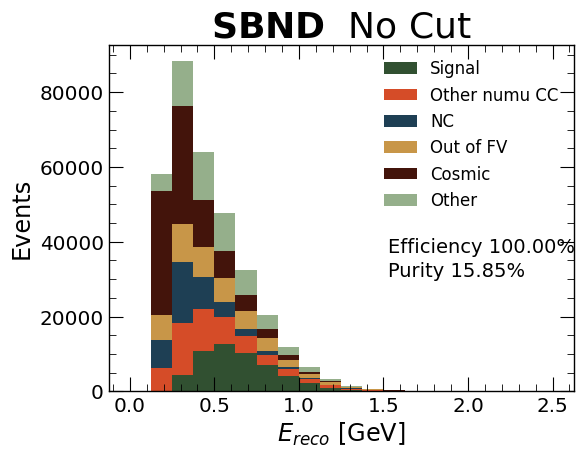

<Figure size 640x480 with 0 Axes>

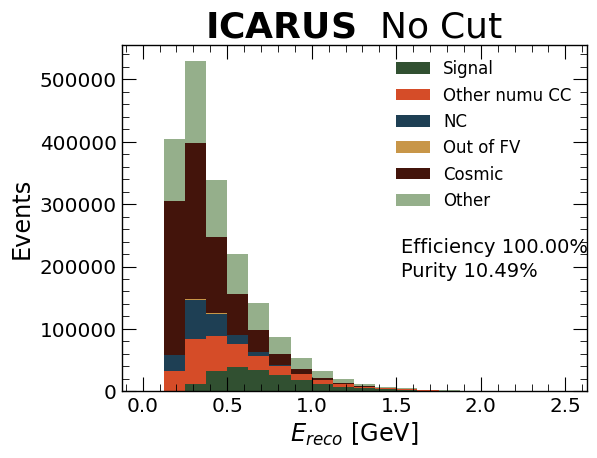

<Figure size 640x480 with 0 Axes>

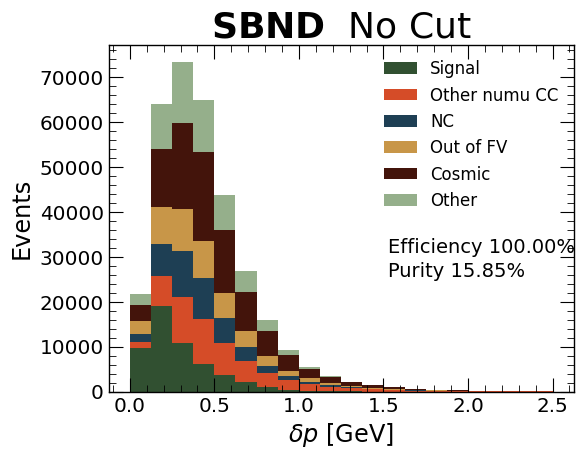

<Figure size 640x480 with 0 Axes>

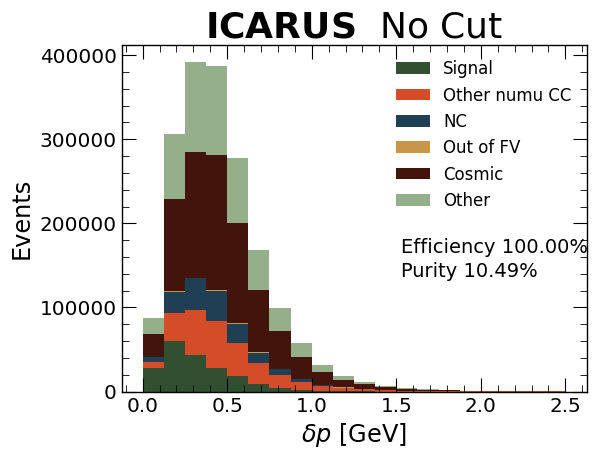

<Figure size 640x480 with 0 Axes>

In [54]:
# Grab some plots w/o cuts
sbnd_comp, icarus_comp = make_all_plots(df_nd, df_fd, "No Cut", mode_labels, top_labels, det_labels)
comp_sbnd.append(sbnd_comp)
comp_icarus.append(icarus_comp)

/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:105: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[True True True ... True True True]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  ret = FVRun2


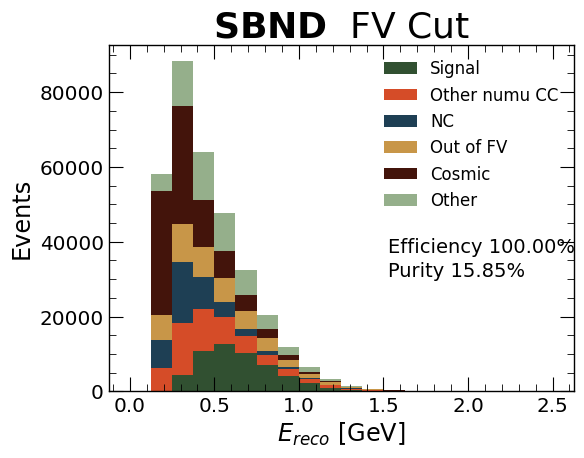

<Figure size 640x480 with 0 Axes>

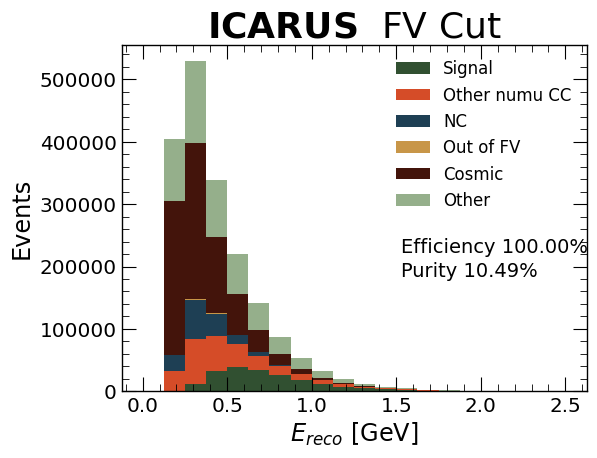

<Figure size 640x480 with 0 Axes>

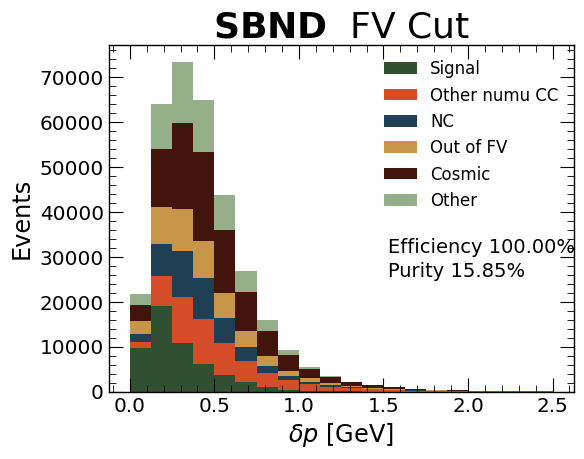

<Figure size 640x480 with 0 Axes>

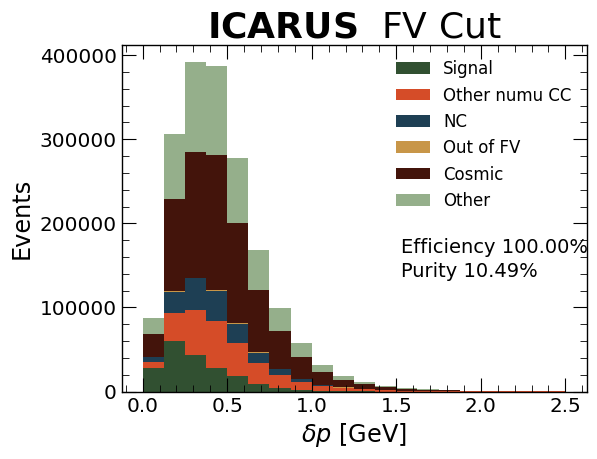

<Figure size 640x480 with 0 Axes>

In [55]:
# FV Cut
df_nd = df_nd[gc.slcfv_cut(df_nd, "SBND")]
df_fd = df_fd[gc.slcfv_cut(df_fd, "ICARUS")]
sbnd_comp, icarus_comp = make_all_plots(df_nd, df_fd, "FV Cut", mode_labels, top_labels, det_labels)

comp_sbnd.append(sbnd_comp)
comp_icarus.append(icarus_comp)

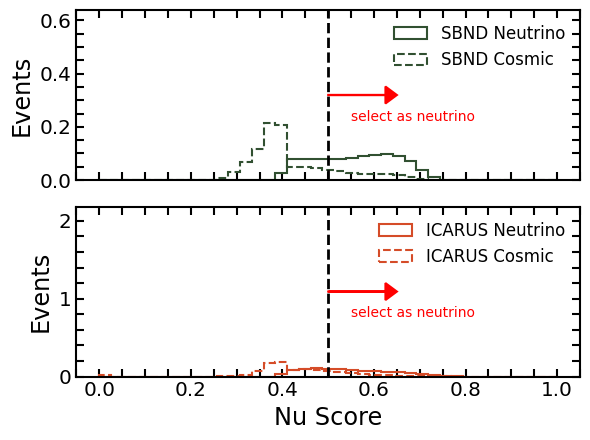

<Figure size 640x480 with 0 Axes>

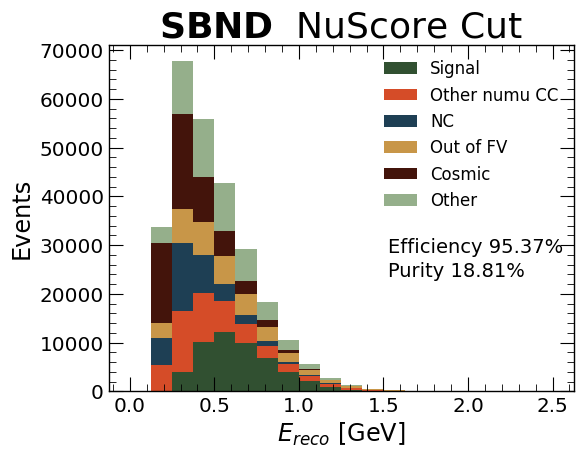

<Figure size 640x480 with 0 Axes>

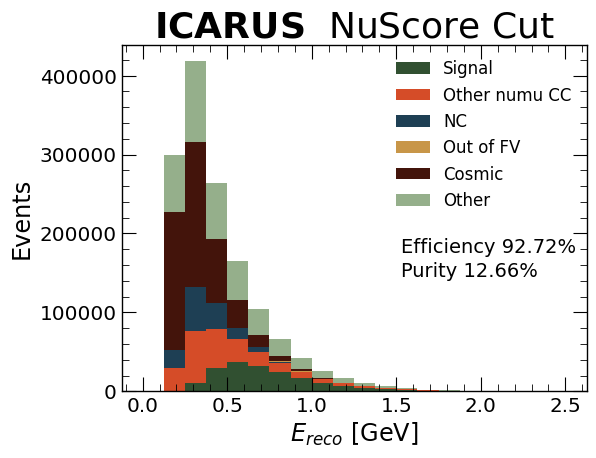

<Figure size 640x480 with 0 Axes>

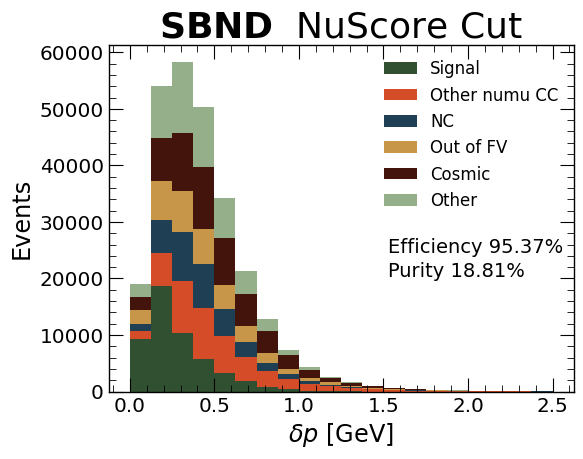

<Figure size 640x480 with 0 Axes>

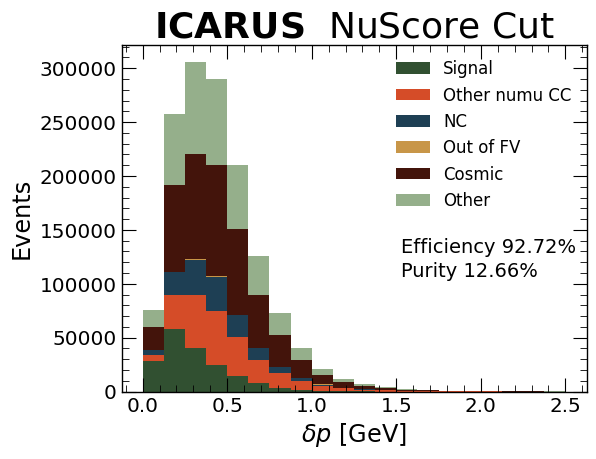

<Figure size 640x480 with 0 Axes>

In [56]:
# NuScore cut
plot_nuscore_cut([
    df_nd.nu_score[gc.cosmic_cut(df_nd)], df_nd.nu_score[np.invert(gc.cosmic_cut(df_nd))]
], [0.5], [
    df_fd.nu_score[gc.cosmic_cut(df_fd)], df_fd.nu_score[np.invert(gc.cosmic_cut(df_fd))]
], [0.5], "NuScore", "NuScore.png", [0, 1],
    ['SBND Neutrino', 'SBND Cosmic', 'ICARUS Neutrino', 'ICARUS Cosmic'], 'right', 'select as neutrino')

df_nd = df_nd[gc.cosmic_cut(df_nd)]
df_fd = df_fd[gc.cosmic_cut(df_fd)]
sbnd_comp, icarus_comp = make_all_plots(df_nd, df_fd, "NuScore Cut", mode_labels, top_labels, det_labels)
comp_sbnd.append(sbnd_comp)
comp_icarus.append(icarus_comp)

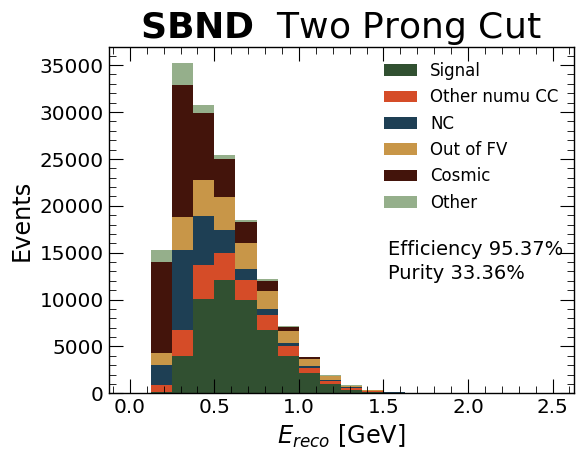

<Figure size 640x480 with 0 Axes>

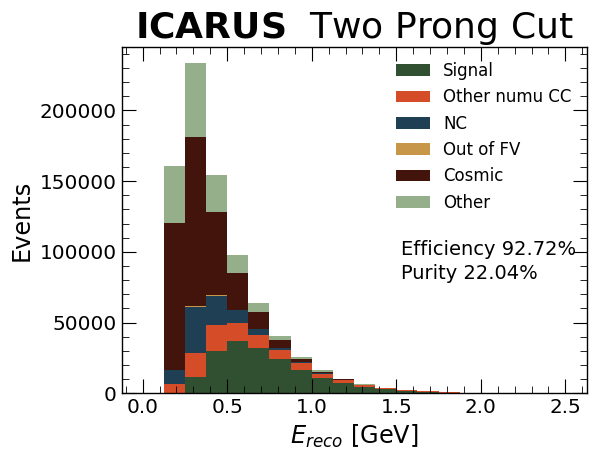

<Figure size 640x480 with 0 Axes>

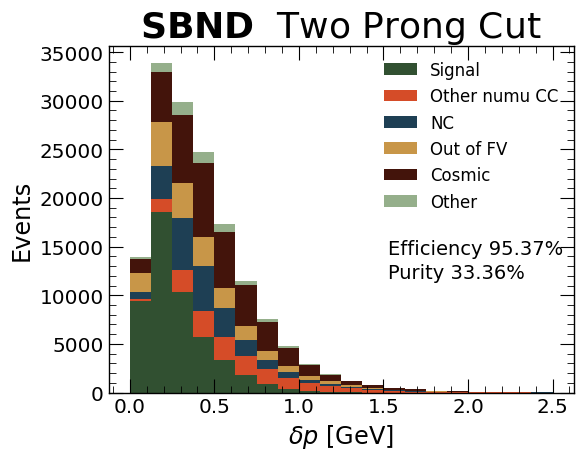

<Figure size 640x480 with 0 Axes>

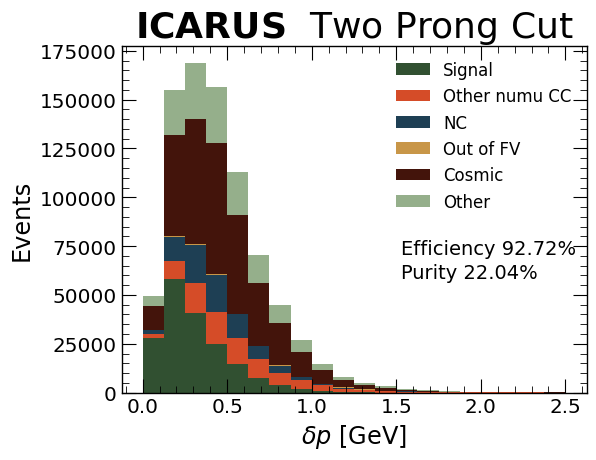

<Figure size 640x480 with 0 Axes>

In [57]:
# Two prong cut
df_nd = df_nd[gc.twoprong_cut(df_nd)]
df_fd = df_fd[gc.twoprong_cut(df_fd)]
sbnd_comp, icarus_comp = make_all_plots(df_nd, df_fd, "Two Prong Cut", mode_labels, top_labels, det_labels)
comp_sbnd.append(sbnd_comp)
comp_icarus.append(icarus_comp)

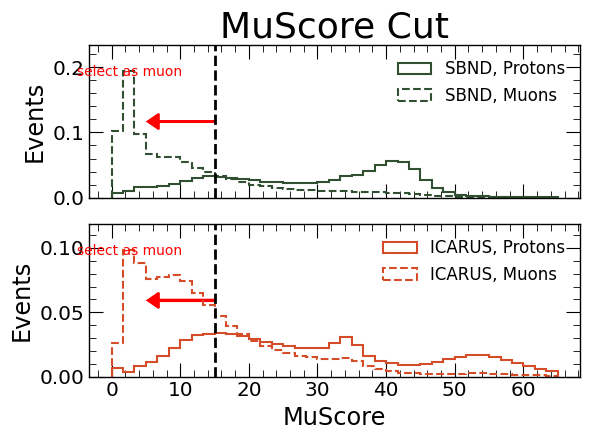

<Figure size 640x480 with 0 Axes>

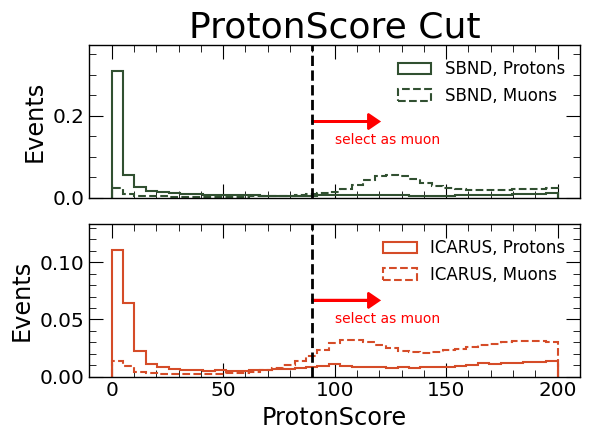

<Figure size 640x480 with 0 Axes>

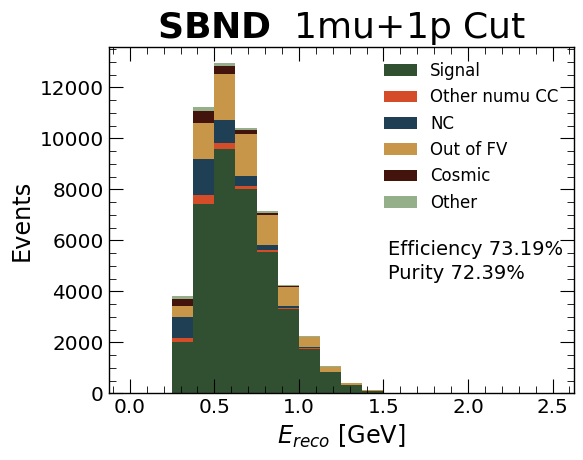

<Figure size 640x480 with 0 Axes>

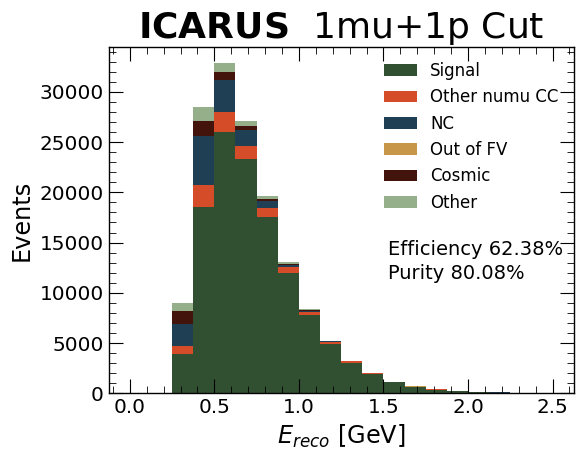

<Figure size 640x480 with 0 Axes>

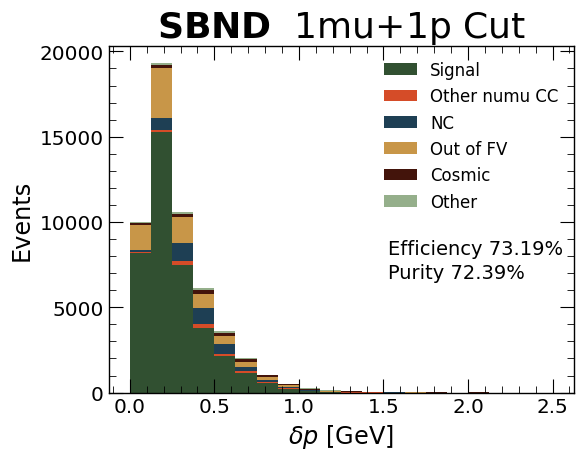

<Figure size 640x480 with 0 Axes>

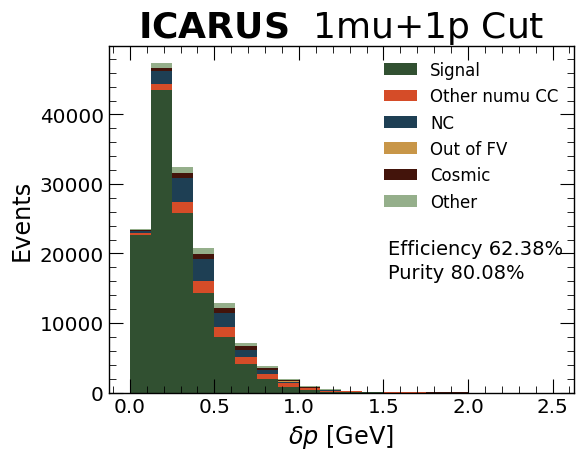

<Figure size 640x480 with 0 Axes>

In [58]:
# PID cuts
plot_PID_cut([[df_nd.mu_chi2_of_prot_cand, df_nd.mu_chi2_of_mu_cand],
              [df_fd.mu_chi2_of_prot_cand, df_fd.mu_chi2_of_mu_cand]],
              [15, 15], "MuScore", "MuScore.png", [0, 65],
              ['SBND, Protons', 'SBND, Muons', 'ICARUS, Protons', 'ICARUS, Muons'],
              'left', 'select as muon')

plot_PID_cut([[df_nd.prot_chi2_of_prot_cand, df_nd.prot_chi2_of_mu_cand],
              [df_fd.prot_chi2_of_prot_cand, df_fd.prot_chi2_of_mu_cand]],
              [90, 90], "ProtonScore", "ProtonScore.png", [0, 200],
              ['SBND, Protons', 'SBND, Muons', 'ICARUS, Protons', 'ICARUS, Muons'],
              'right', 'select as muon')

df_nd = df_nd[gc.pid_cut(df_nd.mu_chi2_of_mu_cand, df_nd.mu_chi2_of_prot_cand, 
                      df_nd.prot_chi2_of_mu_cand, df_nd.prot_chi2_of_prot_cand, df_nd.mu_len)]
df_fd = df_fd[gc.pid_cut(df_fd.mu_chi2_of_mu_cand, df_fd.mu_chi2_of_prot_cand, 
                      df_fd.prot_chi2_of_mu_cand, df_fd.prot_chi2_of_prot_cand, df_fd.mu_len)]
sbnd_comp, icarus_comp = make_all_plots(df_nd, df_fd, "1mu+1p Cut", mode_labels, top_labels, det_labels)
comp_sbnd.append(sbnd_comp)
comp_icarus.append(icarus_comp)

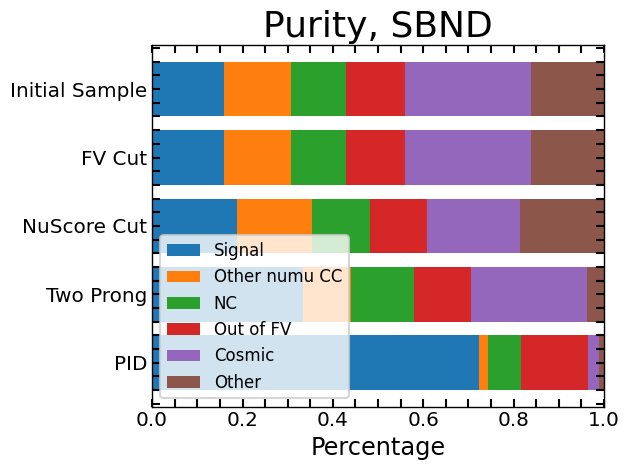

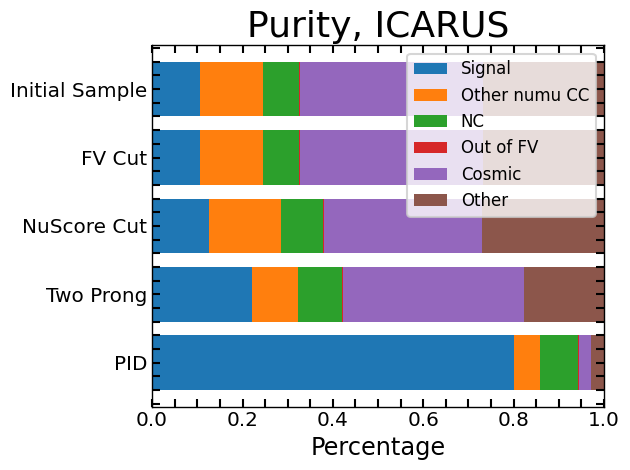

<Figure size 640x480 with 0 Axes>

In [59]:
# Composition plots
plot_composition(np.array(comp_sbnd), cut_labels, top_labels, 'SBND', 'SBNDComp.png')
plot_composition(np.array(comp_icarus), cut_labels, top_labels, 'ICARUS', 'ICARUSComp.png')